# Utilisation d'un modèle pré-entraîné (CNN)

Dans ce notebook, nous n'allons **pas** ré-entraîner le réseau de neurones. 
Nous allons simplement charger le modèle que nous avons déjà sauvegardé (`modelcnn.keras`) et l'utiliser pour faire des prédictions.

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import load_model
from keras.datasets import mnist

## 1. Chargement du modèle existant
On utilise la fonction `load_model` de Keras pour récupérer les poids et l'architecture du réseau sans aucun temps de calcul.

In [11]:
# Chargement du modèle sauvegardé
model_path = os.path.join('model', 'modelcnn.keras')
model = load_model(model_path)

# Affichons le résumé pour vérifier que c'est bien notre CNN
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 576)               0

## 2. Chargement de données de test
Pour tester notre modèle, on va charger les 10 000 images de test de MNIST. On ne touche pas aux images d'entraînement !

In [12]:
(_, _), (test_images, test_labels) = mnist.load_data()

# On normalise et on redimensionne comme pour l'entraînement
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255.0

print("Shape des images de test :", test_images.shape)

Shape des images de test : (10000, 28, 28, 1)


## 3. Prédiction sur quelques images
Nous allons tirer au hasard quelques images, demander au modèle de deviner le chiffre, et afficher le résultat en image.

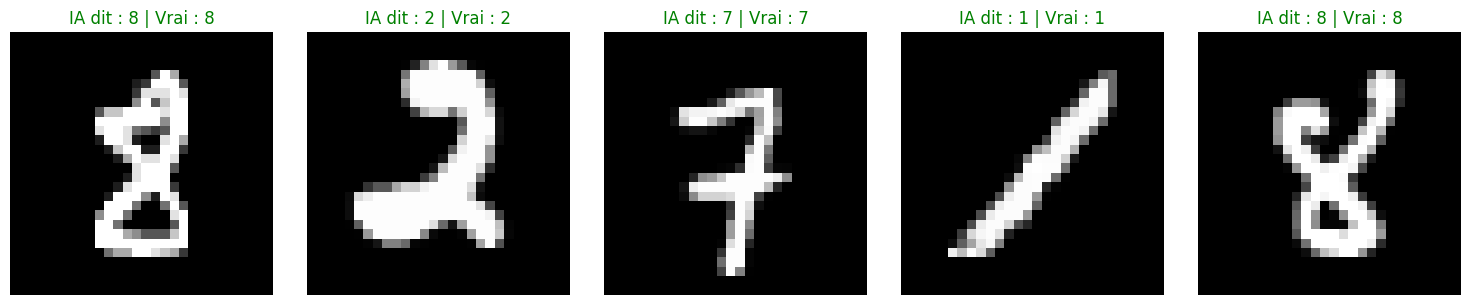

In [13]:
import random

# On choisit 5 images au hasard dans le jeu de test
indices = random.sample(range(len(test_images)), 5)

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):
    # Récupération de l'image
    img = test_images[idx]
    
    # La prédiction attend un tableau (batch) d'images, on ajoute une dimension -> (1, 28, 28, 1)
    img_batch = np.expand_dims(img, axis=0)
    
    # L'IA calcule les probabilités
    predictions = model.predict(img_batch, verbose=0)
    
    # On prend l'index de la probabilité la plus haute
    predicted_digit = np.argmax(predictions)
    actual_digit = test_labels[idx]
    
    # Affichage
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    
    # Vert si l'IA a juste, Rouge si l'IA s'est trompée
    color = 'green' if predicted_digit == actual_digit else 'red'
    plt.title(f"IA dit : {predicted_digit} | Vrai : {actual_digit}", color=color)

plt.tight_layout()
plt.show()

## 4. Test sur vos propres images (dossier `images`)
On va maintenant tester notre modèle sur les vraies images dessinées à la main (ou extraites de Paint) et sauvegardées dans le dossier `images`.

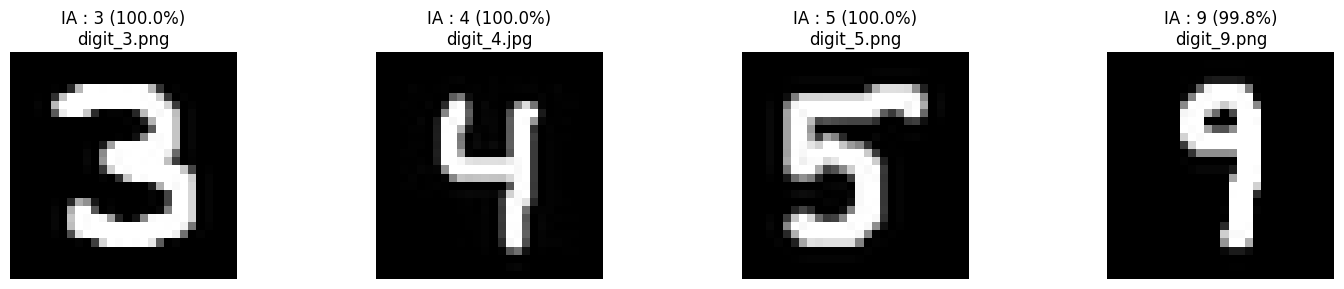

In [14]:
from PIL import Image, ImageOps
import glob

def preprocess_image(image_path):
    """Prépare l'image exactement comme les images de la base MNIST"""
    img = Image.open(image_path).convert('L')       # Niveaux de gris
    img = ImageOps.invert(img)                       # Inversion des couleurs (texte blanc, fond noir)

    # 1. On coupe tout le vide autour du chiffre (Bounding Box)
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)

        # 2. On rend l'image parfaitement carrée (pour éviter qu'elle soit écrasée)
        w, h = img.size
        max_side = max(w, h)
        pad_w = (max_side - w) // 2
        pad_h = (max_side - h) // 2
        img = ImageOps.expand(img, border=(pad_w, pad_h, pad_w, pad_h), fill=0)

        # 3. On rajoute la petite marge noire caractéristique des images MNIST (4 pixels)
        img = ImageOps.expand(img, border=4, fill=0)

    # 4. Enfin, on réduit tout proprement en 28x28
    img = img.resize((28, 28), Image.LANCZOS)
    
    # Conversion mathématique pour Keras
    img_array = np.array(img).astype('float32') / 255.0
    img_batch = img_array.reshape(1, 28, 28, 1)
    
    return img_batch, img

# On liste toutes les images dans le dossier 'images'
image_files = glob.glob(os.path.join('images', '*.*'))

if not image_files:
    print("Aucune image trouvée dans le dossier 'images'.")
else:
    plt.figure(figsize=(15, 3))
    
    for i, img_path in enumerate(image_files[:5]): # On limite à 5 images pour l'affichage
        # Prétraitement rigoureux
        img_batch, img_pil = preprocess_image(img_path)
        
        # Prédiction
        predictions = model.predict(img_batch, verbose=0)
        predicted_digit = np.argmax(predictions)
        prob = np.amax(predictions) * 100
        
        # Affichage
        plt.subplot(1, len(image_files[:5]), i + 1)
        plt.imshow(img_pil, cmap='gray')
        plt.axis('off')
        plt.title(f"IA : {predicted_digit} ({prob:.1f}%)\n{os.path.basename(img_path)}")

    plt.tight_layout()
    plt.show()